Connected to: c:\Users\Tejas\Desktop\mf_project\data\db\bluestock_mf.db
VaR/CVaR report saved.
Rolling Sharpe chart saved.
Cohort analysis:
   cohort_year     avg_amount  total_invested  top_fund
0         2024  107739.476605      2500633252    119094
1         2025  106704.345527      1020947178    119551
At-risk investors: 2762
HHI sample:
   scheme_code        HHI
0       100016  38.951166
1       100025  37.482659
2       100033  36.645456
3       101206  39.363852
4       101207  37.095315
All analytics completed successfully.


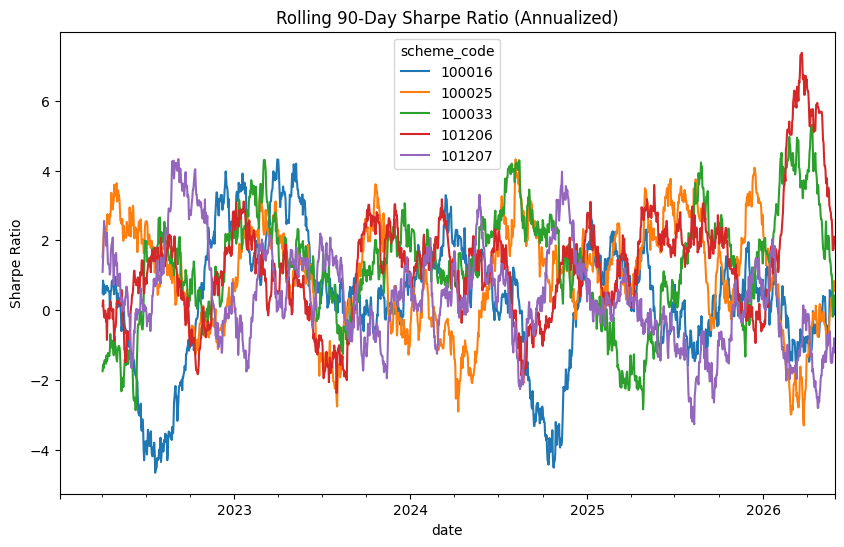

In [2]:
import os
from pathlib import Path

def _find_project_root(marker="data/db"):
    p = Path(os.getcwd())
    for _ in range(6):
        if (p / marker).exists():
            return p
        p = p.parent
    raise RuntimeError("Cannot locate project root. Run notebook from mf_project/")

_ROOT   = _find_project_root()
db_path = str(_ROOT / "data" / "db" / "bluestock_mf.db")
if not Path(db_path).exists() or Path(db_path).stat().st_size == 0:
    raise FileNotFoundError(
        f"DB not found or empty: {db_path}\n"
        "Run: python scripts/rebuild_db.py"
    )

import sqlite3
import numpy as np
import pandas as pd

conn = sqlite3.connect(db_path)
print('Connected to:', db_path)

# 1. NAV data & returns
df_nav = pd.read_sql_query('SELECT date, scheme_code, nav FROM fact_nav;', conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_pivot   = df_nav.pivot(index='date', columns='scheme_code', values='nav').sort_index()
df_returns = df_pivot.pct_change().dropna(how='all')

# 2. Transactions
df_tx = pd.read_sql_query('SELECT * FROM fact_transactions;', conn)
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])
conn.close()

# 3. VaR / CVaR
var_95  = df_returns.quantile(0.05)
cvar_95 = df_returns[df_returns <= var_95].mean()
var_cvar_report = pd.DataFrame({'95_VaR': var_95, '95_CVaR': cvar_95})
var_cvar_report.to_csv(str(_ROOT / 'reports' / 'var_cvar_report.csv'))
print('VaR/CVaR report saved.')

# 4. Rolling Sharpe (90-day)
key_funds = list(df_returns.columns[:5])
rolling_sharpe = (
    df_returns[key_funds].rolling(90).mean()
    / df_returns[key_funds].rolling(90).std()
) * np.sqrt(252)
ax = rolling_sharpe.plot(title='Rolling 90-Day Sharpe Ratio (Annualized)', figsize=(10, 6))
ax.set_ylabel('Sharpe Ratio')
ax.figure.savefig(str(_ROOT / 'reports' / 'rolling_sharpe_chart.png'))
print('Rolling Sharpe chart saved.')

# 5. Cohort analysis
df_tx['cohort_year'] = df_tx['transaction_date'].dt.year
cohort_analysis = (
    df_tx.groupby('cohort_year')
    .agg(
        avg_amount=('amount', 'mean'),
        total_invested=('amount', 'sum'),
        top_fund=('scheme_code', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    )
    .reset_index()
)
print('Cohort analysis:')
print(cohort_analysis)

# 6. SIP continuity / at-risk investors
df_sip = df_tx.sort_values(['investor_id', 'transaction_date']).copy()
df_sip['days_gap'] = df_sip.groupby('investor_id')['transaction_date'].diff().dt.days
eligible = df_tx['investor_id'].value_counts()
eligible = eligible[eligible >= 6].index
continuity_df = df_sip[df_sip['investor_id'].isin(eligible)].copy()
investor_risk = (
    continuity_df.groupby('investor_id')['days_gap']
    .mean()
    .reset_index(name='avg_days_gap')
)
investor_risk['status'] = np.where(investor_risk['avg_days_gap'] > 35, 'at-risk', 'active')
print('At-risk investors:', (investor_risk['status'] == 'at-risk').sum())

# 7. Fund concentration HHI
# reset_index(name=...) prevents 'cannot insert <col>, already exists' error
fund_alloc = (
    df_tx.groupby(['scheme_code', 'investor_id'])['amount']
    .sum()
    .reset_index(name='inv_amount')
)
fund_totals = (
    df_tx.groupby('scheme_code')['amount']
    .sum()
    .reset_index(name='total_fund_amt')
)
alloc_weights = fund_alloc.merge(fund_totals, on='scheme_code')
alloc_weights['weight'] = alloc_weights['inv_amount'] / alloc_weights['total_fund_amt']
hhi_df = (
    alloc_weights.groupby('scheme_code')['weight']
    .apply(lambda w: np.sum((w * 100) ** 2))
    .reset_index(name='HHI')
)
print('HHI sample:')
print(hhi_df.head())
print('All analytics completed successfully.')


![Sharpe Ratio Chart](rolling_sharpe_chart.png)